# E-commerce User Behaviour Analysis

This project explores how users interact with an online cosmetics platform, focusing on how they move from browsing products to making a purchase.

## Data Loading

In [4]:
import pandas as pd

df = pd.read_csv("data/2019-Nov.csv", nrows=100000)

df.head()


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:02 UTC,view,5802432,1487580009286598681,NaN,NaN,0.32,562076640,09fafd6c-6c99-46b1-834f-33527f4de241
1,2019-11-01 00:00:09 UTC,cart,5844397,1487580006317032337,NaN,NaN,2.38,553329724,2067216c-31b5-455d-a1cc-af0575a34ffb
2,2019-11-01 00:00:10 UTC,view,5837166,1783999064103190764,NaN,pnb,22.22,556138645,57ed222e-a54a-4907-9944-5a875c2d7f4f
3,2019-11-01 00:00:11 UTC,cart,5876812,1487580010100293687,NaN,jessnail,3.16,564506666,186c1951-8052-4b37-adce-dd9644b1d5f7
4,2019-11-01 00:00:24 UTC,remove_from_cart,5826182,1487580007483048900,NaN,NaN,3.33,553329724,2067216c-31b5-455d-a1cc-af0575a34ffb


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     100000 non-null  object 
 1   event_type     100000 non-null  object 
 2   product_id     100000 non-null  int64  
 3   category_id    100000 non-null  int64  
 4   category_code  1614 non-null    object 
 5   brand          60918 non-null   object 
 6   price          100000 non-null  float64
 7   user_id        100000 non-null  int64  
 8   user_session   99956 non-null   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 6.9+ MB


## Data Preparation

In [6]:
# Convert time
df['event_time'] = pd.to_datetime(df['event_time'])

# Keep only key events
df = df[df['event_type'].isin(['view', 'cart', 'purchase'])]

# Drop missing users
df = df.dropna(subset=['user_id'])

## Data Preparation Insight
The dataset contains missing values in certain descriptive fields such as product category and brand. However, core behavioral variables such as event type, timestamp, and user identifiers are complete, allowing for reliable analysis of user interaction patterns.

## Event Distribution

In [7]:
df['event_type'].value_counts(normalize=True)

event_type
view        0.566605
cart        0.352621
purchase    0.080775
Name: proportion, dtype: float64

## Event Distribution Insight

The distribution of user interactions reveals that a significant proportion of users progress from viewing products to adding them to the cart. However, a substantial drop off occurs at the final stage of the funnel, with only a small percentage of users completing purchases. 

This suggests that while user interest and intent are relatively high, barriers exist at the point of conversion. These may include price sensitivity, hesitation in decision-making, or friction in the checkout process.

## Funnel Analysis

In [8]:
user_funnel = df.pivot_table(
    index='user_id',
    columns='event_type',
    aggfunc='size',
    fill_value=0
)

user_funnel['viewed'] = user_funnel['view'] > 0
user_funnel['carted'] = user_funnel['cart'] > 0
user_funnel['purchased'] = user_funnel['purchase'] > 0

In [9]:
view_to_cart = user_funnel['carted'].sum() / user_funnel['viewed'].sum()
cart_to_purchase = user_funnel['purchased'].sum() / user_funnel['carted'].sum()
view_to_purchase = user_funnel['purchased'].sum() / user_funnel['viewed'].sum()

view_to_cart, cart_to_purchase, view_to_purchase

(0.27239913371300234, 0.23409893992932862, 0.06376834843988129)

## Funnel Analysis

Around 27% of users who view products go on to add items to their cart, which shows that users are genuinely interested and willing to explore products further.

This was interesting because I initially expected more users to drop off earlier in the funnel, but instead most users reach the cart stage.

However, only about 23% of those users actually complete a purchase, leading to an overall conversion rate of roughly 6%. This suggests that even though users are interested, many do not follow through to complete the purchase.

The biggest drop happens at the cart stage, which may be due to factors like price concerns, hesitation, or issues during checkout.

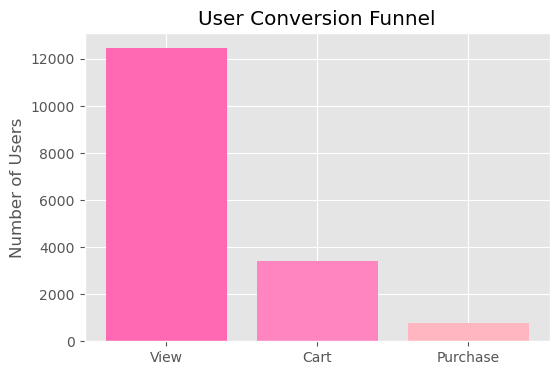

In [28]:
import matplotlib.pyplot as plt

stages = [
    user_funnel['viewed'].sum(),
    user_funnel['carted'].sum(),
    user_funnel['purchased'].sum()
]

labels = ['View', 'Cart', 'Purchase']

plt.figure(figsize=(6,4))

plt.bar(labels, stages, color=['#ff69b4', '#ff85c1', '#ffb6c1'])

plt.title("User Conversion Funnel")
plt.style.use('ggplot')
plt.ylabel("Number of Users")

plt.show()

## Time to Purchase Analysis

In [21]:
first_view = df[df['event_type']=='view'].groupby('user_id')['event_time'].min()
first_purchase = df[df['event_type']=='purchase'].groupby('user_id')['event_time'].min()

time_diff = (first_purchase - first_view).dropna()

# convert to hours
time_diff = time_diff.dt.total_seconds() / 3600

# remove invalid negative values
time_diff = time_diff[time_diff >= 0]

time_diff.describe()

count    675.000000
mean       1.463719
std        2.389825
min        0.008333
25%        0.185694
50%        0.515000
75%        1.493056
max       18.288056
Name: event_time, dtype: float64

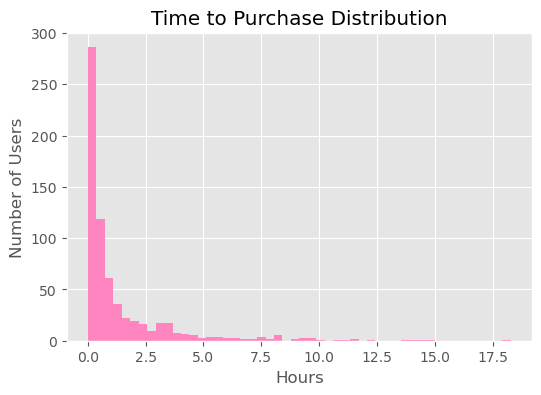

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(time_diff, bins=50, color='#ff85c1')

plt.title("Time to Purchase Distribution")
plt.xlabel("Hours")
plt.ylabel("Number of Users")

plt.show()

## Time to Purchase Insight

The data shows that most users complete their purchase quite quickly after viewing a product, often within the first hour. This suggests that many decisions are made fast, without much delay.

However, some users take longer to complete their purchase, which may mean they are comparing options or returning later before making a decision.

Overall, this shows that there are two types of behavior: some users make quick decisions, while others take more time before buying.

## Repeat User Analysis(New vs Repeat Users)

In [24]:
user_counts = df.groupby('user_id').size()

repeat_users = user_counts[user_counts > 5].index
df['repeat_user'] = df['user_id'].isin(repeat_users)

df.groupby('repeat_user')['event_type'].value_counts(normalize=True)


repeat_user  event_type
False        view          0.880593
             cart          0.111693
             purchase      0.007713
True         view          0.481208
             cart          0.418147
             purchase      0.100645
Name: proportion, dtype: float64

## Repeat User Behavior Insight

The analysis reveals a clear difference between new and repeat users. New users primarily engage in browsing behavior, with a very small proportion completing purchases. In contrast, repeat users show significantly higher engagement, with a much larger share progressing to cart and purchase stages.

Notably, repeat users are far more likely to complete a purchase compared to new users. This suggests that familiarity with the platform, trust, and prior experience play a crucial role in driving conversions.

These findings highlight the importance of user retention strategies, as returning users contribute disproportionately to actual purchases.

## Price Analysis

In [27]:
df.groupby('event_type')['price'].mean()

event_type
cart         4.985002
purchase     4.912193
view        12.973011
Name: price, dtype: float64

## Price Analysis Insight

From the data, it looks like users often view higher priced products, but end up buying cheaper ones. 

This suggests that while users are interested in more expensive items, they may hesitate when it comes to actually purchasing them. Instead, they seem to choose more affordable options.

This could also be one of the reasons for the drop off in the funnel, especially at the later stages, where users decide whether to complete the purchase or not.

## Conclusion

This analysis shows that while many users engage with products and add items to their cart, only a smaller proportion go on to complete purchases. This suggests that improving the final stages of the purchase process could significantly increase conversions.

The price analysis also shows that users often view higher priced products but tend to purchase cheaper ones, indicating that price may influence the final decision.

This analysis also helped me better understand how user behavior changes across different stages of the purchase journey.

It also highlights the importance of repeat users, who are far more likely to complete purchases compared to new users.